In [2]:
# Install extra libs (timm has pretrained food models)
!pip install timm -q
!pip install albumentations -q

import os, json, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Device — auto-detects T4x2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device} | GPUs: {torch.cuda.device_count()}")

Using: cuda | GPUs: 2


In [3]:
CFG = {
    'data_dir':    '/kaggle/input/datasets/yacineabh/algerian-food/Clean Dataset',
    'output_dir':  '/kaggle/working',
    'model_name':  'efficientnet_b0',   # mobile-friendly
    'img_size':    224,
    'batch_size':  64,                   # per GPU, so 128 total
    'epochs':      30,
    'lr':          1e-3,
    'weight_decay':1e-4,
    'val_split':   0.15,
    'test_split':  0.10,
    'num_workers': 4,
    'label_smooth':0.1,
    'mixup_alpha': 0.2,
    'patience':    7,                   # early stopping
}

In [4]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

# Load full dataset (no transforms yet)
full_ds = ImageFolder(root=CFG['data_dir'])
CLASS_NAMES = full_ds.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

# Save class names for mobile app
with open(f"{CFG['output_dir']}/class_names.json", 'w') as f:
    json.dump(CLASS_NAMES, f)

# 75 / 15 / 10 split
total = len(full_ds)
test_n  = int(total * CFG['test_split'])
val_n   = int(total * CFG['val_split'])
train_n = total - val_n - test_n

train_ds, val_ds, test_ds = random_split(
    full_ds, [train_n, val_n, test_n],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Train: {train_n} | Val: {val_n} | Test: {test_n}")

Classes (11): ['baklawa', 'chourba', 'couscous', 'egg', 'french fries', 'pizza', 'sfenje', 'spaghetti', 'sushi', 'tajin_zitoun', 'tiramisu']
Train: 5198 | Val: 1039 | Test: 693


In [5]:
# ImageNet stats (EfficientNet was pretrained on ImageNet)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(CFG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2),  # simulate occlusion
])

val_tfm = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(CFG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Assign transforms (wrap subset with custom dataset)
class SubsetWithTransform(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

train_data = SubsetWithTransform(train_ds, train_tfm)
val_data   = SubsetWithTransform(val_ds,   val_tfm)
test_data  = SubsetWithTransform(test_ds,  val_tfm)

In [6]:
# Count samples per class in train split
train_labels = [full_ds.targets[i] for i in train_ds.indices]
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_data, batch_size=CFG['batch_size'],
                          sampler=sampler,
                          num_workers=CFG['num_workers'],
                          pin_memory=True)

val_loader  = DataLoader(val_data,  batch_size=CFG['batch_size']*2,
                         shuffle=False,
                         num_workers=CFG['num_workers'],
                         pin_memory=True)

test_loader = DataLoader(test_data, batch_size=CFG['batch_size']*2,
                         shuffle=False,
                         num_workers=CFG['num_workers'])

In [8]:
# Load EfficientNet-B0 pretrained on ImageNet
# (food-pretrained checkpoint not on timm, but we fine-tune anyway)
model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,        # ImageNet weights
    num_classes=NUM_CLASSES  # replaces head automatically
)

# Wrap for multi-GPU (T4 x2)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

# --- Loss: Label Smoothing handles overconfidence ---
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smooth'])

# --- Optimizer: AdamW with weight decay ---
optimizer = optim.AdamW(model.parameters(),
                        lr=CFG['lr'],
                        weight_decay=CFG['weight_decay'])

# --- Scheduler: Cosine Annealing (smooth LR decay) ---
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-6
)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Using 2 GPUs


In [9]:
def mixup_data(x, y, alpha=0.2):
    """MixUp augmentation — blends two samples"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    idx = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, la, lb, lam = mixup_data(imgs, labels, CFG['mixup_alpha'])
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = mixup_criterion(criterion, outputs, la, lb, lam)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clip
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        correct += (lam * predicted.eq(la).sum().item()
                  + (1 - lam) * predicted.eq(lb).sum().item())
        total += labels.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

# --- Main loop ---
best_val_acc = 0
patience_counter = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(CFG['epochs']):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch+1:02d}/{CFG['epochs']} | "
          f"Train loss: {tr_loss:.4f} acc: {tr_acc:.4f} | "
          f"Val loss: {vl_loss:.4f} acc: {vl_acc:.4f}")

    # Save best checkpoint
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), f"{CFG['output_dir']}/best_model.pth")
        patience_counter = 0
        print(f"  ✓ Saved best model (val_acc={best_val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

Epoch 01/30 | Train loss: 1.6140 acc: 0.6423 | Val loss: 1.0100 acc: 0.8383
  ✓ Saved best model (val_acc=0.8383)
Epoch 02/30 | Train loss: 1.2642 acc: 0.7437 | Val loss: 0.8970 acc: 0.8864
  ✓ Saved best model (val_acc=0.8864)
Epoch 03/30 | Train loss: 1.0707 acc: 0.8142 | Val loss: 0.7617 acc: 0.9172
  ✓ Saved best model (val_acc=0.9172)
Epoch 04/30 | Train loss: 1.0040 acc: 0.8403 | Val loss: 0.7369 acc: 0.9365
  ✓ Saved best model (val_acc=0.9365)
Epoch 05/30 | Train loss: 1.0675 acc: 0.8139 | Val loss: 0.8111 acc: 0.9182
Epoch 06/30 | Train loss: 0.9339 acc: 0.8655 | Val loss: 0.7200 acc: 0.9317
Epoch 07/30 | Train loss: 0.9562 acc: 0.8539 | Val loss: 0.7200 acc: 0.9326
Epoch 08/30 | Train loss: 0.9711 acc: 0.8544 | Val loss: 0.7051 acc: 0.9365
Epoch 09/30 | Train loss: 0.9847 acc: 0.8453 | Val loss: 0.6948 acc: 0.9490
  ✓ Saved best model (val_acc=0.9490)
Epoch 10/30 | Train loss: 0.9145 acc: 0.8706 | Val loss: 0.7195 acc: 0.9326
Epoch 11/30 | Train loss: 0.9305 acc: 0.8650 | Val

              precision    recall  f1-score   support

     baklawa       0.94      0.96      0.95        67
     chourba       1.00      0.98      0.99        56
    couscous       0.95      0.98      0.97        63
         egg       0.99      0.95      0.97        86
french fries       0.92      0.94      0.93        35
       pizza       0.92      0.95      0.94        64
      sfenje       0.94      0.97      0.96        35
   spaghetti       0.96      1.00      0.98        72
       sushi       0.97      0.89      0.93        73
tajin_zitoun       0.98      0.97      0.98        65
    tiramisu       0.95      0.96      0.95        77

    accuracy                           0.96       693
   macro avg       0.96      0.96      0.96       693
weighted avg       0.96      0.96      0.96       693



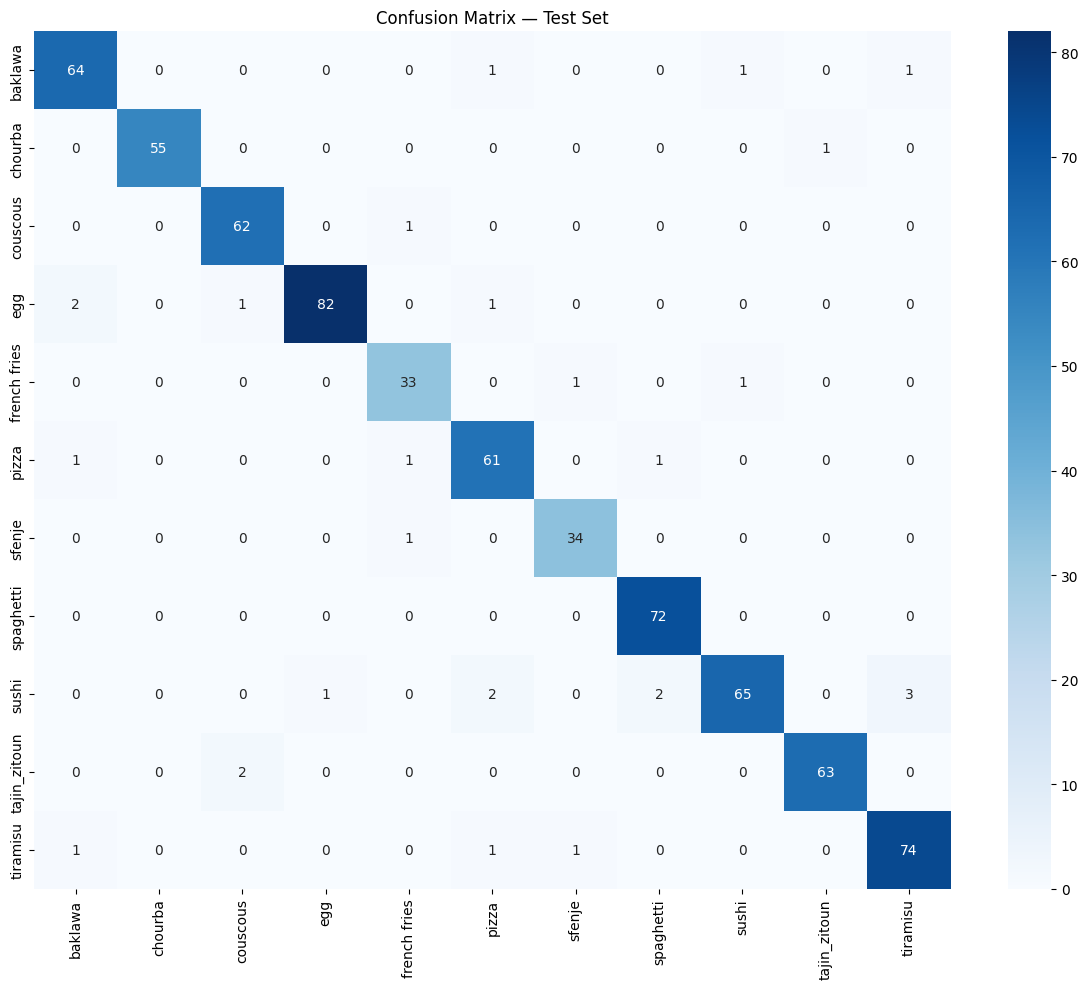

In [25]:
# Load best checkpoint
model.load_state_dict(torch.load(f"{CFG['output_dir']}/best_model.pth"))
model.to(device)  # <--- ADD THIS LINE TO FIX THE ERROR
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Per-class report
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/confusion_matrix.png", dpi=150)
plt.show()

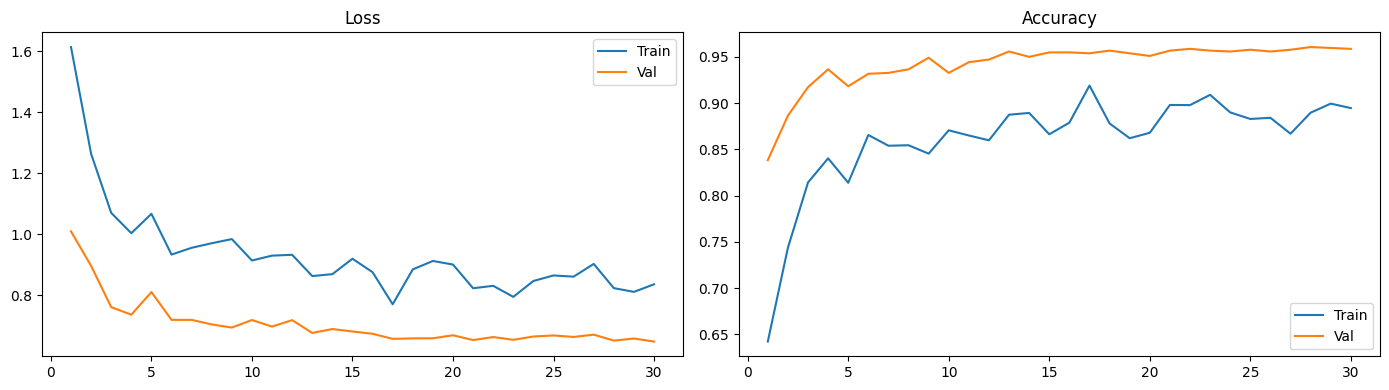

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

ax1.plot(x, history['train_loss'], label='Train')
ax1.plot(x, history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.legend()

ax2.plot(x, history['train_acc'], label='Train')
ax2.plot(x, history['val_acc'], label='Val')
ax2.set_title('Accuracy'); ax2.legend()

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/training_curves.png", dpi=150)
plt.show()

In [39]:
torch.onnx.export(
    raw_model, dummy_input,
    f"{CFG['output_dir']}/food_classifier.onnx",
    export_params=True,
    opset_version=17,        # use 17, not 12
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}},
    dynamo=False             # ← forces legacy exporter, fixes the bug
)

In [41]:
import os

tflite_path = '/kaggle/working/tflite_model/food_classifier_float16.tflite'
size_mb = os.path.getsize(tflite_path) / 1e6
print(f"TFLite model size: {size_mb:.1f} MB ✓")

# Copy to working root for easy download
import shutil
shutil.copy(tflite_path, '/kaggle/working/food_classifier_fp16.tflite')
print("Copied to /kaggle/working/ ✓")

TFLite model size: 8.1 MB ✓
Copied to /kaggle/working/ ✓


In [42]:
from PIL import Image
import onnxruntime as ort

session = ort.InferenceSession('/kaggle/working/food_classifier.onnx')

def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    arr = np.array(img).astype(np.float32) / 255.0
    arr = (arr - np.array(MEAN)) / np.array(STD)
    arr = arr.transpose(2, 0, 1)[np.newaxis]  # HWC → 1CHW
    logits = session.run(None, {'input': arr})[0]
    probs = np.exp(logits) / np.exp(logits).sum()
    top_idx = probs.argmax()
    return {
        'class': CLASS_NAMES[top_idx],
        'confidence': f"{probs[0][top_idx]*100:.1f}%",
        'top3': [(CLASS_NAMES[i], f"{probs[0][i]*100:.1f}%")
                  for i in probs[0].argsort()[::-1][:3]]
    }

In [44]:
import os
import zipfile

zip_path = "/kaggle/working/final_export.zip"

# files you want explicitly
files_to_zip = [
    "best_model.pth",
    "class_names.json",
    "confusion_matrix.png",
    "food_classifier.onnx",
    "food_classifier.onnx.data",
    "food_classifier.tflite",
    "food_classifier_fp16.tflite",
    "training_curves.png",
]

# folders you want (recursive)
folders_to_zip = [
    "tflite_model"
]

ignore_file = "output.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:

    # add files
    for f in files_to_zip:
        path = os.path.join("/kaggle/working", f)
        if os.path.exists(path) and f != ignore_file:
            zipf.write(path, arcname=f)

    # add folders recursively
    for folder in folders_to_zip:
        folder_path = os.path.join("/kaggle/working", folder)

        for root, _, files in os.walk(folder_path):
            for file in files:
                full_path = os.path.join(root, file)

                # skip any accidental zip
                if "output.zip" in full_path:
                    continue

                arcname = os.path.relpath(full_path, "/kaggle/working")
                zipf.write(full_path, arcname)

print("Created:", zip_path)

Created: /kaggle/working/final_export.zip
